In [1]:
import os
from google.colab import drive
import scipy.io
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
from keras.applications import  VGG16, MobileNet
from tensorflow import keras
from keras import models, layers
from keras.models import Model
from keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from keras.regularizers import l2
import seaborn as sns
from tensorflow.keras.preprocessing import image

In [2]:
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
image_path = '/content/gdrive/MyDrive/flowers/'

In [4]:
files = os.listdir(image_path)
files = [item for item in files if ')' not in item]
images = [item for item in files if 'ipynb_checkpoints' not in item]
print("Number of images in dataset:",len(images))

Number of images in dataset: 8189


In [5]:
images.sort()


In [6]:
print(f"images: {images[:5]}...")

images: ['image_00001.jpg', 'image_00002.jpg', 'image_00003.jpg', 'image_00004.jpg', 'image_00005.jpg']...


In [7]:
labels = scipy.io.loadmat('/content/gdrive/MyDrive/imagelabels.mat')
splits = scipy.io.loadmat('/content/gdrive/MyDrive/setid.mat')

print("labels type : ", type(labels))
print("splits type: ", type(splits))

labels type :  <class 'dict'>
splits type:  <class 'dict'>


In [8]:
label = labels['labels']

print("Length of Labels:", label.size)

print("***Printing length of set id's of training testing and validation set***")

print('Length of Testing set:', splits['trnid'].size)
print('Length of Training set : ', splits['tstid'].size)
print('Length of validation set:', splits['valid'].size)

Length of Labels: 8189
***Printing length of set id's of training testing and validation set***
Length of Testing set: 1020
Length of Training set :  6149
Length of validation set: 1020


In [9]:
sets = ['../content/Training', '../content/Testing', '../content/Validation']

for i in sets:
    os.mkdir(i)
    for j in range(1, 103):
        os.mkdir(i + f'/{j}')

In [10]:
import shutil

def copy_images(image_ids, images, image_path, destination_folder, label):
    for img_id in image_ids:
        img = images[img_id - 1]
        source = image_path + img
        destination = f"../content/{destination_folder}/{label[0][img_id-1]}"
        shutil.copy(source, destination)

def split_and_copy_images(splits, images, image_path, label):
    print("Start splitting....")

    print("Copying testing data.....")
    copy_images(splits['trnid'][0], images, image_path, "Testing", label)

    print("Copying validation data.....")
    copy_images(splits['valid'][0], images, image_path, "Validation", label)

    print("Copying training data.....")
    copy_images(splits['tstid'][0], images, image_path, "Training", label)

    print("Splitting finished")


split_and_copy_images(splits, images, image_path, label)

Start splitting....
Copying testing data.....
Copying validation data.....
Copying training data.....
Splitting finished


In [11]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
)

train_generator = train_datagen.flow_from_directory(
    '../content/Training',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    color_mode='rgb'
)

# Validation ImageDataGenerator
valid_datagen = ImageDataGenerator(rescale=1./255)

valid_generator = valid_datagen.flow_from_directory(
    '../content/Validation',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False,
)

# Testing ImageDataGenerator
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    '../content/Testing',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False,
)

Found 6149 images belonging to 102 classes.
Found 1020 images belonging to 102 classes.
Found 1020 images belonging to 102 classes.


In [12]:
base_model = VGG16(include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers:
    layer.trainable = False

x = Flatten()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
predictions = Dense(102, activation='softmax')(x)

58889256/58889256 [==============================] - 2s 0us/step


In [13]:
 model = Model(inputs=base_model.input, outputs=predictions)

 model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [14]:
early_stoping = EarlyStopping(monitor='val_loss',patience=3,verbose=1)

In [15]:
history=model.fit(train_generator, epochs=60, validation_data=valid_generator,callbacks=[early_stoping])

Epoch 1/60
193/193 [==============================] - 110s 504ms/step - loss: 4.2241 - accuracy: 0.1049 - val_loss: 4.0643 - val_accuracy: 0.1127
Epoch 2/60
193/193 [==============================] - 95s 493ms/step - loss: 3.5566 - accuracy: 0.2165 - val_loss: 3.5381 - val_accuracy: 0.2216
Epoch 3/60
193/193 [==============================] - 92s 478ms/step - loss: 3.1516 - accuracy: 0.2911 - val_loss: 3.1335 - val_accuracy: 0.2735
Epoch 4/60
193/193 [==============================] - 96s 497ms/step - loss: 2.8490 - accuracy: 0.3527 - val_loss: 2.7596 - val_accuracy: 0.3794
Epoch 5/60
193/193 [==============================] - 94s 487ms/step - loss: 2.6193 - accuracy: 0.3854 - val_loss: 2.5001 - val_accuracy: 0.4353
Epoch 6/60
193/193 [==============================] - 94s 485ms/step - loss: 2.4279 - accuracy: 0.4289 - val_loss: 2.3323 - val_accuracy: 0.4490
Epoch 7/60
193/193 [==============================] - 93s 483ms/step - loss: 2.2777 - accuracy: 0.4484 - val_loss: 2.0962 - val_a

In [16]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

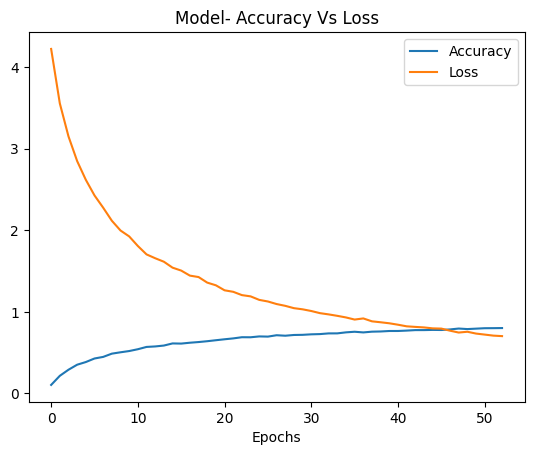

In [17]:
plt.plot(range(len(model.history.history['accuracy'])),model.history.history['accuracy'])
plt.plot(range(len(model.history.history['loss'])),model.history.history['loss'])
plt.title('Model- Accuracy Vs Loss')
plt.xlabel('Epochs')
plt.legend(['Accuracy', 'Loss'])
plt.show()

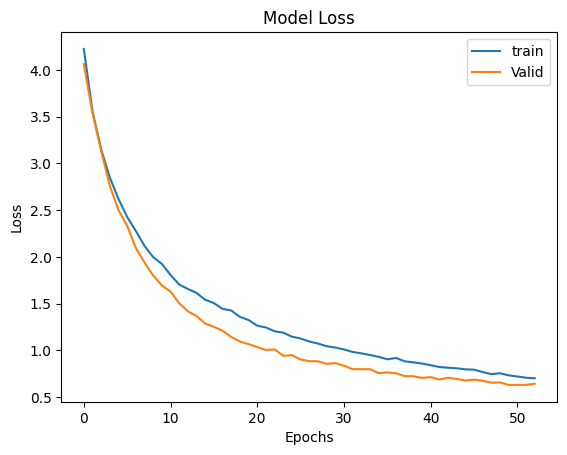

In [18]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['train', 'Valid'])
plt.show()

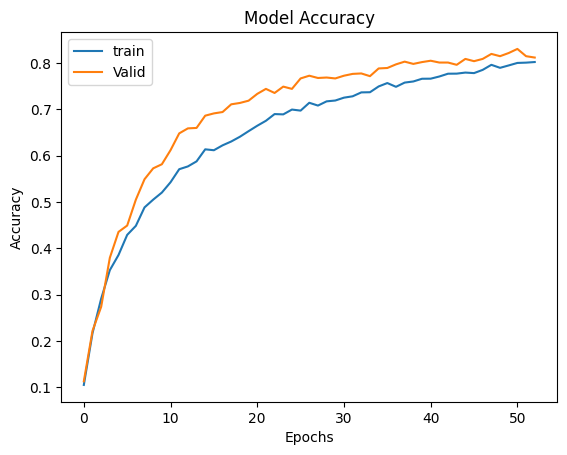

In [19]:
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'Valid'])
plt.show()

In [20]:
loss, accuracy = model.evaluate(test_generator)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

32/32 [==============================] - 4s 123ms/step - loss: 0.7720 - accuracy: 0.7912
Test Loss: 0.7720, Test Accuracy: 0.7912


In [21]:
label_names = ['pink primrose','hard-leaved pocket orchid','canterbury bells','sweet pea','english marigold','tiger lily','moon orchid','bird of paradise',
'monkshood','globe thistle','snapdragon',"colt's foot",'king protea','spear thistle','yellow iris','globe-flower',
'purple coneflower','peruvian lily','balloon flower','giant white arum lily','fire lily','pincushion flower','fritillary','red ginger',
'grape hyacinth','corn poppy','prince of wales feathers','stemless gentian','artichoke','sweet william','carnation','garden phlox','love in the mist',
'mexican aster','alpine sea holly','ruby-lipped cattleya','cape flower','great masterwort','siam tulip','lenten rose','barbeton daisy','daffodil',
'sword lily','poinsettia','bolero deep blue','wallflower','marigold','buttercup','oxeye daisy','common dandelion','petunia','wild pansy','primula',
'sunflower','pelargonium','bishop of llandaff','gaura','geranium','orange dahlia','pink-yellow dahlia?','cautleya spicata','japanese anemone',
'black-eyed susan','silverbush','californian poppy','osteospermum','spring crocus','bearded iris','windflower','tree poppy','gazania','azalea',
'water lily','rose','thorn apple','morning glory','passion flower','lotus','toad lily','anthurium','frangipani','clematis','hibiscus','columbine',
'desert-rose','tree mallow','magnolia','cyclamen ','watercress','canna lily','hippeastrum ','bee balm','ball moss','foxglove','bougainvillea',
'camellia','mallow','mexican petunia','bromelia','blanket flower','trumpet creeper','blackberry lily']

In [22]:
label_dict = {i + 1: label_names[i] for i in range(len(label_names))}

# Print the label dictionary
print(label_dict)

{1: 'pink primrose', 2: 'hard-leaved pocket orchid', 3: 'canterbury bells', 4: 'sweet pea', 5: 'english marigold', 6: 'tiger lily', 7: 'moon orchid', 8: 'bird of paradise', 9: 'monkshood', 10: 'globe thistle', 11: 'snapdragon', 12: "colt's foot", 13: 'king protea', 14: 'spear thistle', 15: 'yellow iris', 16: 'globe-flower', 17: 'purple coneflower', 18: 'peruvian lily', 19: 'balloon flower', 20: 'giant white arum lily', 21: 'fire lily', 22: 'pincushion flower', 23: 'fritillary', 24: 'red ginger', 25: 'grape hyacinth', 26: 'corn poppy', 27: 'prince of wales feathers', 28: 'stemless gentian', 29: 'artichoke', 30: 'sweet william', 31: 'carnation', 32: 'garden phlox', 33: 'love in the mist', 34: 'mexican aster', 35: 'alpine sea holly', 36: 'ruby-lipped cattleya', 37: 'cape flower', 38: 'great masterwort', 39: 'siam tulip', 40: 'lenten rose', 41: 'barbeton daisy', 42: 'daffodil', 43: 'sword lily', 44: 'poinsettia', 45: 'bolero deep blue', 46: 'wallflower', 47: 'marigold', 48: 'buttercup', 49

In [23]:
numbers_list = [1, 10, 100, 101, 102, 11, 12, 13, 14, 15, 16, 17, 18, 19, 2, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 3, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 4, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 5, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 6, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 7, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 8, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 9, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]


flowers_list = [label_dict[number] for number in numbers_list]

# Print the resulting list
print(flowers_list)

['pink primrose', 'globe thistle', 'blanket flower', 'trumpet creeper', 'blackberry lily', 'snapdragon', "colt's foot", 'king protea', 'spear thistle', 'yellow iris', 'globe-flower', 'purple coneflower', 'peruvian lily', 'balloon flower', 'hard-leaved pocket orchid', 'giant white arum lily', 'fire lily', 'pincushion flower', 'fritillary', 'red ginger', 'grape hyacinth', 'corn poppy', 'prince of wales feathers', 'stemless gentian', 'artichoke', 'canterbury bells', 'sweet william', 'carnation', 'garden phlox', 'love in the mist', 'mexican aster', 'alpine sea holly', 'ruby-lipped cattleya', 'cape flower', 'great masterwort', 'siam tulip', 'sweet pea', 'lenten rose', 'barbeton daisy', 'daffodil', 'sword lily', 'poinsettia', 'bolero deep blue', 'wallflower', 'marigold', 'buttercup', 'oxeye daisy', 'english marigold', 'common dandelion', 'petunia', 'wild pansy', 'primula', 'sunflower', 'pelargonium', 'bishop of llandaff', 'gaura', 'geranium', 'orange dahlia', 'tiger lily', 'pink-yellow dahli

1/1 [==============================] - 0s 55ms/step
0.8119442


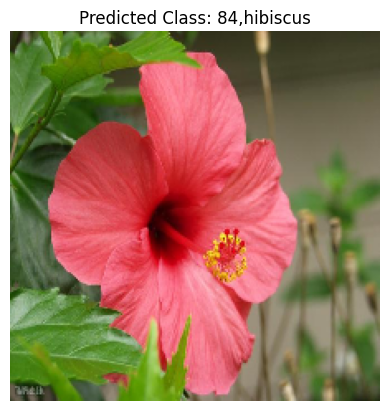

In [34]:



img = image.load_img('/content/image_01705.jpg', target_size=(224, 224))
img_array = image.img_to_array(img)


img_array = np.expand_dims(img_array, axis=0)
img_array/= 255.



predictions = model.predict(img_array)


predicted_class_index = np.argmax(predictions, axis=1)[0]

predicted_confidence = predictions[0][predicted_class_index]

predicted_class = flowers_list[predicted_class_index]

print(predicted_confidence)
plt.imshow(img)  # Assuming batch size is 1
plt.axis('off')
plt.title(f"Predicted Class: {predicted_class_index},{predicted_class}")
plt.show()

1/1 [==============================] - 0s 66ms/step
0.53057635


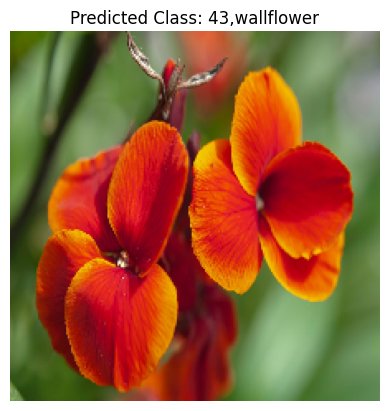

In [35]:

img = image.load_img('/content/wallflower-plant-profile-4799246-04-15a197b16d294834962aa9ade81571a8.jpg', target_size=(224, 224))  # Adjust target_size as per your model's input shape
img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)
img_array/= 255.
predictions = model.predict(img_array)

predicted_class_index = np.argmax(predictions, axis=1)[0]

predicted_confidence = predictions[0][predicted_class_index]

predicted_class = flowers_list[predicted_class_index]

print(predicted_confidence)

plt.imshow(img)
plt.axis('off')
plt.title(f"Predicted Class: {predicted_class_index},{predicted_class}")
plt.show()

1/1 [==============================] - 0s 76ms/step
0.6190962


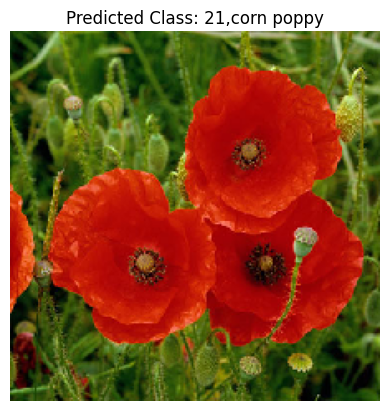

In [37]:


img = image.load_img('/content/corn-poppy-papaver-rhoeas-mature.jpg', target_size=(224, 224))  # Adjust target_size as per your model's input shape
img_array = image.img_to_array(img)


img_array = np.expand_dims(img_array, axis=0)
img_array/= 255.


predictions = model.predict(img_array)

predicted_class_index = np.argmax(predictions, axis=1)[0]

predicted_confidence = predictions[0][predicted_class_index]

predicted_class = flowers_list[predicted_class_index]

print(predicted_confidence)

plt.imshow(img)
plt.axis('off')
plt.title(f"Predicted Class: {predicted_class_index},{predicted_class}")
plt.show()

1/1 [==============================] - 0s 28ms/step
0.9999999


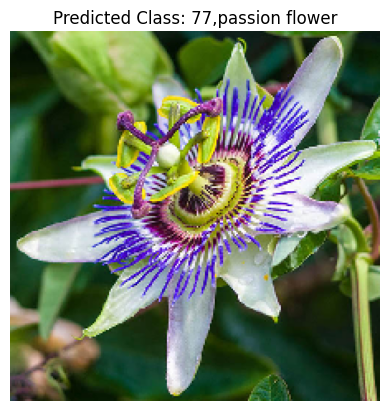

In [38]:



img = image.load_img('/content/550334.jpg', target_size=(224, 224))  # Adjust target_size as per your model's input shape
img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)
img_array/= 255.
predictions = model.predict(img_array)

predicted_class_index = np.argmax(predictions, axis=1)[0]

predicted_confidence = predictions[0][predicted_class_index]

predicted_class = flowers_list[predicted_class_index]

print(predicted_confidence)

plt.imshow(img)
plt.axis('off')
plt.title(f"Predicted Class: {predicted_class_index},{predicted_class}")
plt.show()

1/1 [==============================] - 0s 33ms/step
0.97657937


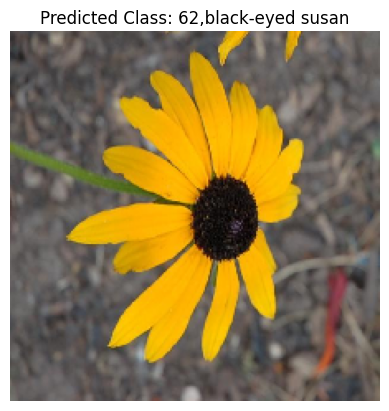

In [39]:


img = image.load_img('/content/bd5b0373-8b3f-4e70-9661-ec5cc02dd2ba.jpeg', target_size=(224, 224))  # Adjust target_size as per your model's input shape
img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)
img_array/= 255.
predictions = model.predict(img_array)


predicted_class_index = np.argmax(predictions, axis=1)[0]

predicted_confidence = predictions[0][predicted_class_index]

predicted_class = flowers_list[predicted_class_index]

print(predicted_confidence)
plt.imshow(img)
plt.axis('off')
plt.title(f"Predicted Class: {predicted_class_index},{predicted_class}")
plt.show()

In [40]:
for i in range(len(true_labels)):
    if true_labels[i] != predicted_labels[i]:
        print(f"Mismatch at index {i}: True label - {true_labels[i]}, Predicted label - {predicted_labels[i]}")
        j=j+1

print(j)

Mismatch at index 2: True label - 0, Predicted label - 84
Mismatch at index 3: True label - 0, Predicted label - 49
Mismatch at index 5: True label - 0, Predicted label - 49
Mismatch at index 6: True label - 0, Predicted label - 49
Mismatch at index 7: True label - 0, Predicted label - 49
Mismatch at index 8: True label - 0, Predicted label - 49
Mismatch at index 9: True label - 0, Predicted label - 72
Mismatch at index 23: True label - 2, Predicted label - 38
Mismatch at index 24: True label - 2, Predicted label - 77
Mismatch at index 30: True label - 3, Predicted label - 96
Mismatch at index 31: True label - 3, Predicted label - 5
Mismatch at index 32: True label - 3, Predicted label - 74
Mismatch at index 33: True label - 3, Predicted label - 97
Mismatch at index 34: True label - 3, Predicted label - 89
Mismatch at index 35: True label - 3, Predicted label - 43
Mismatch at index 37: True label - 3, Predicted label - 72
Mismatch at index 39: True label - 3, Predicted label - 89
Misma

In [42]:
model.save('my_model.h5')

In [43]:
import tensorflow as tf

model = tf.keras.models.load_model('/content/my_model.h5')
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
open("model.tflite", "wb").write(tflite_model)

84664092